In [11]:
# Set-up

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


In [20]:
# laoding_data
df = pd.read_csv("funnel_analysis_data.csv")
df.shape
df.head()

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag
0,USR00001,SES00001,Browse,2026-01-12 23:16:16,Desktop,Germany,Organic,Electronics,0.0,Yes
1,USR00002,SES00002,Browse,2026-01-03 03:33:09,Tablet,Germany,Organic,Grocery,0.0,Yes
2,USR00002,SES00002,Add to Cart,2026-01-03 03:36:09,Tablet,UK,Paid Ads,Books,0.0,Yes
3,USR00002,SES00002,Checkout,2026-01-03 03:39:09,Mobile,Germany,Email,Electronics,0.0,Yes
4,USR00003,SES00003,Browse,2026-01-27 09:17:03,Mobile,Germany,Paid Ads,Books,0.0,Yes


In [12]:
# Corporate Styling

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print("Everything is fine")


Everything is fine


In [13]:
# Find Total columns name and number of columns

print(df.columns)

print(f"\nTotal Number of Columns {df.columns.nunique()}")


Index(['User_ID', 'Session_ID', 'Event', 'Timestamp', 'Device', 'Region',
       'Channel', 'Product_Category', 'Revenue', 'Bounce_Flag'],
      dtype='object')

Total Number of Columns 10


In [15]:
df.dtypes

User_ID              object
Session_ID           object
Event                object
Timestamp            object
Device               object
Region               object
Channel              object
Product_Category     object
Revenue             float64
Bounce_Flag          object
dtype: object

In [28]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
print(df.dtypes)


User_ID                     object
Session_ID                  object
Event                       object
Timestamp           datetime64[ns]
Device                      object
Region                      object
Channel                     object
Product_Category            object
Revenue                    float64
Bounce_Flag                 object
dtype: object


In [18]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21461 entries, 0 to 21460
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   User_ID           21461 non-null  object        
 1   Session_ID        21461 non-null  object        
 2   Event             21461 non-null  object        
 3   Timestamp         21461 non-null  datetime64[ns]
 4   Device            21461 non-null  object        
 5   Region            21461 non-null  object        
 6   Channel           21461 non-null  object        
 7   Product_Category  21461 non-null  object        
 8   Revenue           21461 non-null  float64       
 9   Bounce_Flag       21461 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(8)
memory usage: 1.6+ MB


In [21]:
# imp information about dataset's numeric columns

df.describe()


,Revenue
count,21461.000000
mean,54.400117
std,267.596068
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1997.870000


# Data preprocessing And Cleaning


In [24]:
# check for the null and duplicate values

print("\n----Finding Null Values----\n")
null_values = df.isnull().sum()
print(null_values)

print("\n----Finding Duplicate Values----\n")
duplicate_values = df.duplicated().sum()
print(f"Total numbers of duplicate values in this dataset is {duplicate_values}")

print("\n----Total Unique Data----\n")
unique_data = df.nunique()
print(unique_data)



----Finding Null Values----

User_ID             0
Session_ID          0
Event               0
Timestamp           0
Device              0
Region              0
Channel             0
Product_Category    0
Revenue             0
Bounce_Flag         0
dtype: int64

----Finding Duplicate Values----

Total numbers of duplicate values in this dataset is 0

----Total Unique Data----

User_ID             10000
Session_ID          10000
Event                   4
Timestamp           21374
Device                  3
Region                  4
Channel                 4
Product_Category        4
Revenue              1020
Bounce_Flag             2
dtype: int64


In [29]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')


In [30]:
df.dtypes


User_ID                     object
Session_ID                  object
Event                       object
Timestamp           datetime64[ns]
Device                      object
Region                      object
Channel                     object
Product_Category            object
Revenue                    float64
Bounce_Flag                 object
dtype: object

In [31]:
df['Timestamp'].isna().sum()


np.int64(0)

In [35]:
df['Date'] = df['Timestamp'].dt.date
df['DayOfWeek'] = df['Timestamp'].dt.day_name()
df['Hour'] = df['Timestamp'].dt.hour
df['WeekNumber'] = df['Timestamp'].dt.isocalendar().week
df.head()


,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag,Date,DayOfWeek,Hour,WeekNumber
0,USR00001,SES00001,Browse,2026-01-12 23:16:16,Desktop,Germany,Organic,Electronics,0.0,Yes,2026-01-12,Monday,23,3
1,USR00002,SES00002,Browse,2026-01-03 03:33:09,Tablet,Germany,Organic,Grocery,0.0,Yes,2026-01-03,Saturday,3,1
2,USR00002,SES00002,Add to Cart,2026-01-03 03:36:09,Tablet,UK,Paid Ads,Books,0.0,Yes,2026-01-03,Saturday,3,1
3,USR00002,SES00002,Checkout,2026-01-03 03:39:09,Mobile,Germany,Email,Electronics,0.0,Yes,2026-01-03,Saturday,3,1
4,USR00003,SES00003,Browse,2026-01-27 09:17:03,Mobile,Germany,Paid Ads,Books,0.0,Yes,2026-01-27,Tuesday,9,5


In [37]:
df['Event_sequence'] = df.groupby('Session_ID').cumcount() + 1
df.head()

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag,Date,DayOfWeek,Hour,WeekNumber,Event_sequence
0,USR00001,SES00001,Browse,2026-01-12 23:16:16,Desktop,Germany,Organic,Electronics,0.0,Yes,2026-01-12,Monday,23,3,1
1,USR00002,SES00002,Browse,2026-01-03 03:33:09,Tablet,Germany,Organic,Grocery,0.0,Yes,2026-01-03,Saturday,3,1,1
2,USR00002,SES00002,Add to Cart,2026-01-03 03:36:09,Tablet,UK,Paid Ads,Books,0.0,Yes,2026-01-03,Saturday,3,1,2
3,USR00002,SES00002,Checkout,2026-01-03 03:39:09,Mobile,Germany,Email,Electronics,0.0,Yes,2026-01-03,Saturday,3,1,3
4,USR00003,SES00003,Browse,2026-01-27 09:17:03,Mobile,Germany,Paid Ads,Books,0.0,Yes,2026-01-27,Tuesday,9,5,1


In [38]:
# Basic steps

print(f"Total User ID {df['User_ID'].nunique()}")
print(f"\nTotal Session ID {df['Session_ID'].nunique()}")
print(f"\nDate range {df['Date'].min()} to {df['Date'].max()}")


Total User ID 10000

Total Session ID 10000

Date range 2026-01-02 to 2026-02-01


# Funnel Stage Definition and Session-Level Aggregation


In [40]:
# Define funnel stages in order
funnel_stages = ['Browse', 'Add to Cart', 'Checkout', 'Purchase']

# Create session-level summary
session_summary = df.groupby('Session_ID').agg({
    'User_ID': 'first',
    'Timestamp': ['min', 'max'],
    'Event': lambda x: list(x),
    'Device': 'first',
    'Region': 'first',
    'Channel': 'first',
    'Product_Category': 'first',
    'Revenue': 'max',
    'Bounce_Flag': 'first'
}).reset_index()

# Flatten column names
session_summary.columns = [
    'Session_ID', 'User_ID', 'Session_Start', 'Session_End',
    'Event_Sequence', 'Device', 'Region', 'Channel',
    'Product_Category', 'Revenue', 'Bounce_Flag'
]

# Calculate session duration in minutes
session_summary['Session_Duration_Min'] = (
    session_summary['Session_End'] - session_summary['Session_Start']
).dt.total_seconds() / 60

# Function to identify maximum funnel stage reached
def get_max_funnel_stage(events):
    stage_values = {stage: i for i, stage in enumerate(funnel_stages)}
    max_stage_index = -1
    for event in events:
        if event in stage_values and stage_values[event] > max_stage_index:
            max_stage_index = stage_values[event]
    return funnel_stages[max_stage_index] if max_stage_index != -1 else 'Browse'

# Apply function
session_summary['Max_Funnel_Stage'] = session_summary['Event_Sequence'].apply(get_max_funnel_stage)

print(" Session Summary Created:")
display(session_summary.head())


 Session Summary Created:


,Session_ID,User_ID,Session_Start,Session_End,Event_Sequence,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag,Session_Duration_Min,Max_Funnel_Stage
0,SES00001,USR00001,2026-01-12 23:16:16,2026-01-12 23:16:16,[Browse],Desktop,Germany,Organic,Electronics,0.0,Yes,0.0,Browse
1,SES00002,USR00002,2026-01-03 03:33:09,2026-01-03 03:39:09,"[Browse, Add to Cart, Checkout]",Tablet,Germany,Organic,Grocery,0.0,Yes,6.0,Checkout
2,SES00003,USR00003,2026-01-27 09:17:03,2026-01-27 09:21:03,"[Browse, Add to Cart]",Mobile,Germany,Paid Ads,Books,0.0,Yes,4.0,Add to Cart
3,SES00004,USR00004,2026-01-09 13:13:44,2026-01-09 13:13:44,[Browse],Desktop,India,Social Media,Electronics,0.0,Yes,0.0,Browse
4,SES00005,USR00005,2026-01-29 17:57:32,2026-01-29 17:57:32,[Browse],Desktop,Germany,Social Media,Electronics,0.0,Yes,0.0,Browse


#Overall Funnel Analysis


In [42]:
# ----------- FUNNEL METRICS -----------
funnel_metrics = []

for i, stage in enumerate(funnel_stages):
    if i == 0:
        # First stage (Browse) → all sessions
        count = len(session_summary)
    else:
        # Count sessions that reached at least this stage
        count = len(session_summary[
            session_summary['Max_Funnel_Stage'].isin(funnel_stages[i:])
        ])

    funnel_metrics.append({
        'Stage': stage,
        'Sessions': count,
        'Stage_Order': i
    })

funnel_df = pd.DataFrame(funnel_metrics)

# Conversion Rate
funnel_df['Conversion_Rate (%)'] = (
    funnel_df['Sessions'] / funnel_df['Sessions'].iloc[0] * 100
).round(2)

# Drop Off Rate
funnel_df['Drop_Off_Rate (%)'] = (
    (1 - funnel_df['Sessions'] / funnel_df['Sessions'].shift(1)) * 100
)

funnel_df.loc[funnel_df.index[0], 'Drop_Off_Rate (%)'] = 0
funnel_df['Drop_Off_Rate (%)'] = funnel_df['Drop_Off_Rate (%)'].round(2)

print(" OVERALL FUNNEL ANALYSIS")
display(funnel_df)


# ----------- REVENUE ANALYSIS -----------
revenue_stats = session_summary[
    session_summary['Max_Funnel_Stage'] == 'Purchase'
].agg({
    'Revenue': ['sum', 'mean', 'count']
}).round(2)

print("\n REVENUE ANALYSIS")
print(f"Total Revenue: ${revenue_stats.iloc[0,0]:,.2f}")
print(f"Average Order Value: ${revenue_stats.iloc[1,0]:,.2f}")
print(f"Total Orders: {revenue_stats.iloc[2,0]}")


 OVERALL FUNNEL ANALYSIS


,Stage,Sessions,Stage_Order,Conversion_Rate (%),Drop_Off_Rate (%)
0,Browse,10000,0,100.00,0.00
1,Add to Cart,6934,1,69.34,30.66
2,Checkout,3503,2,35.03,49.48
3,Purchase,1024,3,10.24,70.77



 REVENUE ANALYSIS
Total Revenue: $1,167,480.91
Average Order Value: $1,140.12
Total Orders: 1024.0


#Visualization - Overall Funnel


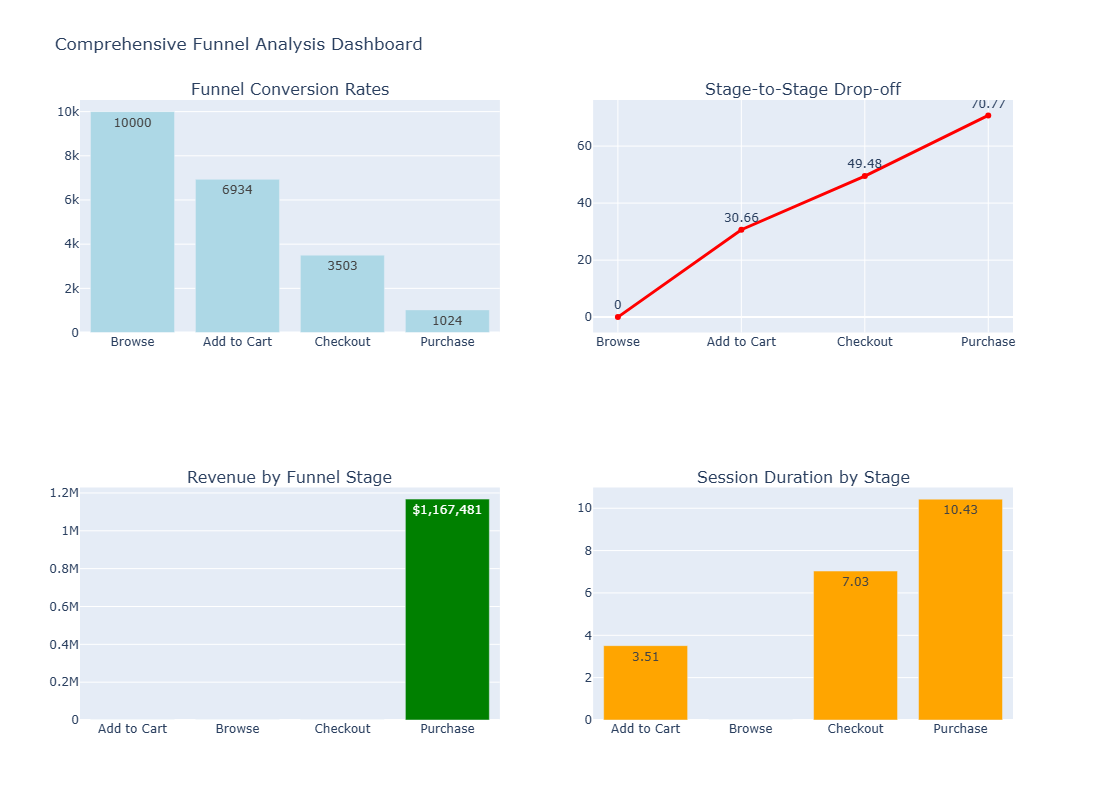

In [48]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Create subplot layout
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Funnel Conversion Rates",
        "Stage-to-Stage Drop-off",
        "Revenue by Funnel Stage",
        "Session Duration by Stage"
    )
)

# ------------------ 1️ Funnel Sessions ------------------
fig.add_trace(
    go.Bar(
        x=funnel_df['Stage'],
        y=funnel_df['Sessions'],
        text=funnel_df['Sessions'],
        textposition='auto',
        name='Sessions',
        marker_color='lightblue'
    ),
    row=1, col=1
)

# ------------------ 2️ Drop-off Rates ------------------
fig.add_trace(
    go.Scatter(
        x=funnel_df['Stage'],
        y=funnel_df['Drop_Off_Rate (%)'],
        mode='lines+markers+text',
        text=funnel_df['Drop_Off_Rate (%)'],
        textposition='top center',
        name='Drop-off Rate (%)',
        line=dict(color='red', width=3)
    ),
    row=1, col=2
)

# ------------------ 3️ Revenue by Stage ------------------
revenue_by_stage = session_summary.groupby('Max_Funnel_Stage')['Revenue'].sum().reset_index()

fig.add_trace(
    go.Bar(
        x=revenue_by_stage['Max_Funnel_Stage'],
        y=revenue_by_stage['Revenue'],
        text=[f"${x:,.0f}" for x in revenue_by_stage['Revenue']],
        textposition='auto',
        name='Revenue',
        marker_color='green'
    ),
    row=2, col=1
)

# ------------------ 4️ Avg Session Duration ------------------
duration_by_stage = session_summary.groupby('Max_Funnel_Stage')['Session_Duration_Min'].mean().reset_index()

fig.add_trace(
    go.Bar(
        x=duration_by_stage['Max_Funnel_Stage'],
        y=duration_by_stage['Session_Duration_Min'],
        text=duration_by_stage['Session_Duration_Min'].round(2),
        textposition='auto',
        name='Avg Session Duration (min)',
        marker_color='orange'
    ),
    row=2, col=2
)

# Layout settings
fig.update_layout(
    height=800,
    title_text="Comprehensive Funnel Analysis Dashboard",
    showlegend=False
)

fig.show()


# Channel Performance Analysis


 Channel Performance Analysis:


,Channel,Total_Sessions,Browse_Sessions,Browse_Rate (%),Add to Cart_Sessions,Add to Cart_Rate (%),Checkout_Sessions,Checkout_Rate (%),Purchase_Sessions,Purchase_Rate (%),Total_Revenue,AOV,Conversion_Rate (%)
0,Organic,2374,2374,100.0,1633,68.79,815,34.33,239,10.07,274265.15,1147.55,10.07
1,Paid Ads,2596,2596,100.0,1840,70.88,941,36.25,287,11.06,333237.98,1161.11,11.06
2,Social Media,2528,2528,100.0,1736,68.67,875,34.61,252,9.97,284849.53,1130.36,9.97
3,Email,2502,2502,100.0,1725,68.94,872,34.85,246,9.83,275128.25,1118.41,9.83


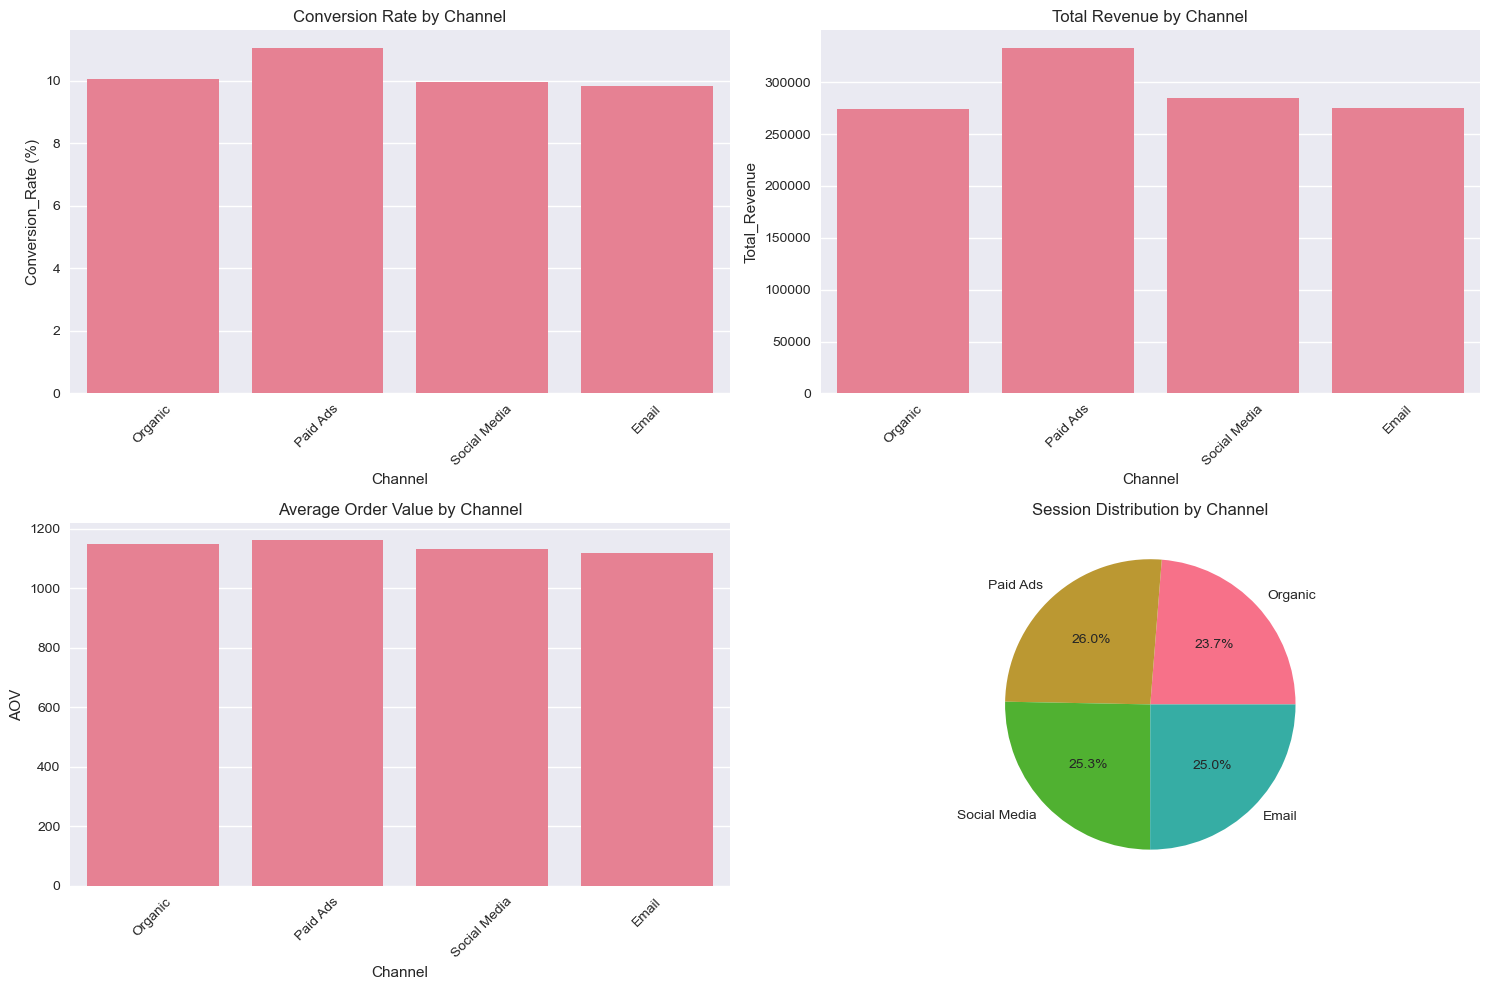

In [49]:
# ==============================
#  CHANNEL PERFORMANCE ANALYSIS
# ==============================

channel_funnel = []

for channel in session_summary['Channel'].unique():
    channel_sessions = session_summary[session_summary['Channel'] == channel]
    total_sessions = len(channel_sessions)

    if total_sessions > 0:
        channel_metrics = {
            'Channel': channel,
            'Total_Sessions': total_sessions
        }

        # -------- Funnel Stage Metrics --------
        for i, stage in enumerate(funnel_stages):
            if i == 0:
                count = total_sessions
            else:
                count = len(channel_sessions[
                    channel_sessions['Max_Funnel_Stage'].isin(funnel_stages[i:])
                ])

            channel_metrics[f'{stage}_Sessions'] = count
            channel_metrics[f'{stage}_Rate (%)'] = (count / total_sessions * 100)

        # -------- Revenue Metrics --------
        purchase_sessions = channel_sessions[
            channel_sessions['Max_Funnel_Stage'] == 'Purchase'
        ]

        channel_metrics['Total_Revenue'] = purchase_sessions['Revenue'].sum()
        channel_metrics['AOV'] = purchase_sessions['Revenue'].mean() if len(purchase_sessions) > 0 else 0
        channel_metrics['Conversion_Rate (%)'] = (len(purchase_sessions) / total_sessions * 100)

        channel_funnel.append(channel_metrics)

# Create DataFrame
channel_df = pd.DataFrame(channel_funnel)

print(" Channel Performance Analysis:")
display(channel_df.round(2))


# ==============================
#  VISUALIZATION
# ==============================

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Conversion rate
sns.barplot(data=channel_df, x='Channel', y='Conversion_Rate (%)', ax=ax1)
ax1.set_title('Conversion Rate by Channel')
ax1.tick_params(axis='x', rotation=45)

# Total revenue
sns.barplot(data=channel_df, x='Channel', y='Total_Revenue', ax=ax2)
ax2.set_title('Total Revenue by Channel')
ax2.tick_params(axis='x', rotation=45)

# AOV
sns.barplot(data=channel_df, x='Channel', y='AOV', ax=ax3)
ax3.set_title('Average Order Value by Channel')
ax3.tick_params(axis='x', rotation=45)

# Session share
channel_df['Session_Percentage'] = channel_df['Total_Sessions'] / channel_df['Total_Sessions'].sum() * 100
ax4.pie(channel_df['Session_Percentage'], labels=channel_df['Channel'], autopct='%1.1f%%')
ax4.set_title('Session Distribution by Channel')

plt.tight_layout()
plt.show()


# Regional Analysis


🌍 Regional Performance:


,Total_Sessions,Total_Revenue,Avg_Session_Duration,Converted_Sessions,Conversion_Rate (%),AOV
Region,,,,,,
Germany,2473,272206.23,3.96,233,9.42,1168.27
India,2618,305422.26,3.98,270,10.31,1131.19
UK,2393,295695.30,4.05,256,10.70,1155.06
US,2516,294157.12,4.07,265,10.53,1110.03


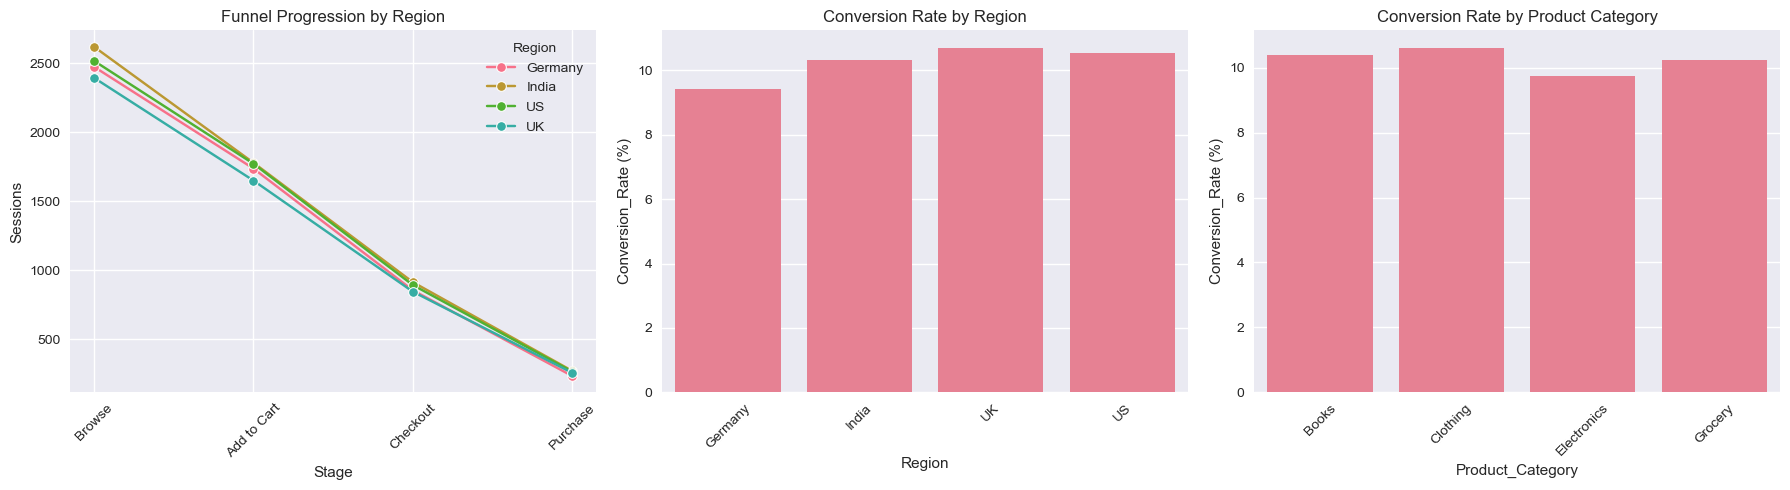

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================
# 📊 REGIONAL PERFORMANCE ANALYSIS
# ==============================

regional_analysis = session_summary.groupby('Region').agg({
    'Session_ID': 'count',
    'Revenue': 'sum',
    'Session_Duration_Min': 'mean'
}).rename(columns={
    'Session_ID': 'Total_Sessions',
    'Revenue': 'Total_Revenue',
    'Session_Duration_Min': 'Avg_Session_Duration'
})

regional_conversion = session_summary[
    session_summary['Max_Funnel_Stage'] == 'Purchase'
].groupby('Region').size()

regional_analysis['Converted_Sessions'] = regional_conversion
regional_analysis['Converted_Sessions'] = regional_analysis['Converted_Sessions'].fillna(0)

regional_analysis['Conversion_Rate (%)'] = (
    regional_analysis['Converted_Sessions'] / regional_analysis['Total_Sessions'] * 100
).round(2)

regional_analysis['AOV'] = (
    regional_analysis['Total_Revenue'] / regional_analysis['Converted_Sessions']
).replace([float('inf')], 0).round(2)

print("🌍 Regional Performance:")
display(regional_analysis.round(2))


# ==============================
# 📈 VISUALIZATIONS
# ==============================

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# 1️⃣ Funnel progression by region
regional_funnel_data = []

for region in session_summary['Region'].unique():
    region_sessions = session_summary[session_summary['Region'] == region]

    for stage in funnel_stages:
        if stage == funnel_stages[0]:
            count = len(region_sessions)
        else:
            count = len(region_sessions[
                region_sessions['Max_Funnel_Stage'].isin(
                    funnel_stages[funnel_stages.index(stage):]
                )
            ])

        regional_funnel_data.append({'Region': region, 'Stage': stage, 'Sessions': count})

regional_funnel_df = pd.DataFrame(regional_funnel_data)

sns.lineplot(data=regional_funnel_df, x='Stage', y='Sessions', hue='Region', marker='o', ax=ax1)
ax1.set_title('Funnel Progression by Region')
ax1.tick_params(axis='x', rotation=45)


# 2️⃣ Conversion rate by region
sns.barplot(
    data=regional_analysis.reset_index(),
    x='Region',
    y='Conversion_Rate (%)',
    ax=ax2
)
ax2.set_title('Conversion Rate by Region')
ax2.tick_params(axis='x', rotation=45)


# 3️⃣ Conversion by product category  ✅ (Tumhara wala chart)
data_product_analysis = session_summary.groupby('Product_Category').agg({
    'Session_ID': 'count',
    'Revenue': 'sum'
}).rename(columns={'Session_ID': 'Sessions'})

product_conversion = session_summary[
    session_summary['Max_Funnel_Stage'] == 'Purchase'
].groupby('Product_Category').size()

data_product_analysis['Conversions'] = product_conversion
data_product_analysis['Conversions'] = data_product_analysis['Conversions'].fillna(0)
data_product_analysis['Conversion_Rate (%)'] = (
    data_product_analysis['Conversions'] / data_product_analysis['Sessions'] * 100
)

sns.barplot(
    data=data_product_analysis.reset_index(),
    x='Product_Category',
    y='Conversion_Rate (%)',
    ax=ax3
)
ax3.set_title('Conversion Rate by Product Category')
ax3.tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()


# device and product data analysis

📱 Device Performance:


,Total_Sessions,Revenue,Session_Duration_Min,Purchases,Conversion_Rate (%),AOV
Device,,,,,,
Desktop,3307,420746.92,4.09,369,11.16,1140.24
Mobile,3358,373546.70,4.00,333,9.92,1121.76
Tablet,3335,373187.29,3.97,322,9.66,1158.97


🛍 Product Category Performance:


,Total_Sessions,Revenue,Purchases,Conversion_Rate (%),AOV,Revenue_per_Session
Product_Category,,,,,,
Books,2553,308071.04,265,10.38,1162.53,120.67
Clothing,2515,295204.69,267,10.62,1105.64,117.38
Electronics,2486,269000.40,242,9.73,1111.57,108.21
Grocery,2446,295204.78,250,10.22,1180.82,120.69


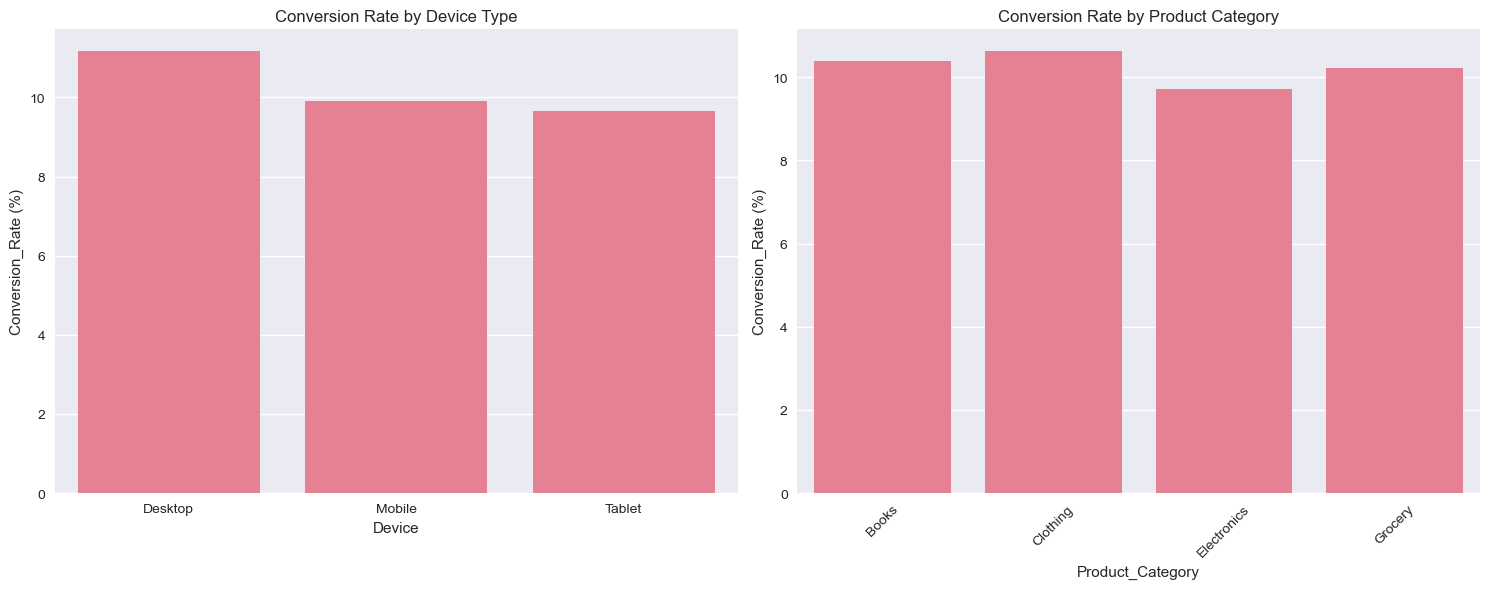

In [52]:
#DEVICE PERFORMANCE
# ==============================

device_analysis = session_summary.groupby('Device').agg({
    'Session_ID': 'count',
    'Revenue': 'sum',
    'Session_Duration_Min': 'mean',
    'Max_Funnel_Stage': lambda x: (x == 'Purchase').sum()
}).rename(columns={
    'Session_ID': 'Total_Sessions',
    'Max_Funnel_Stage': 'Purchases'
})

device_analysis['Conversion_Rate (%)'] = (
    device_analysis['Purchases'] / device_analysis['Total_Sessions'] * 100
).round(2)

device_analysis['AOV'] = (
    device_analysis['Revenue'] / device_analysis['Purchases']
).replace([float('inf')], 0).round(2)

print("📱 Device Performance:")
display(device_analysis.round(2))


# ==============================
# 🛍 PRODUCT CATEGORY PERFORMANCE
# ==============================

product_analysis = session_summary.groupby('Product_Category').agg({
    'Session_ID': 'count',
    'Revenue': 'sum',
    'Max_Funnel_Stage': lambda x: (x == 'Purchase').sum()
}).rename(columns={
    'Session_ID': 'Total_Sessions',
    'Max_Funnel_Stage': 'Purchases'
})

product_analysis['Conversion_Rate (%)'] = (
    product_analysis['Purchases'] / product_analysis['Total_Sessions'] * 100
).round(2)

product_analysis['AOV'] = (
    product_analysis['Revenue'] / product_analysis['Purchases']
).replace([float('inf')], 0).round(2)

product_analysis['Revenue_per_Session'] = (
    product_analysis['Revenue'] / product_analysis['Total_Sessions']
).round(2)

print("🛍 Product Category Performance:")
display(product_analysis.round(2))


# ==============================
# 📊 VISUALIZATION
# ==============================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Device conversion
sns.barplot(
    data=device_analysis.reset_index(),
    x='Device',
    y='Conversion_Rate (%)',
    ax=ax1
)
ax1.set_title('Conversion Rate by Device Type')

# Product category conversion
sns.barplot(
    data=product_analysis.reset_index(),
    x='Product_Category',
    y='Conversion_Rate (%)',
    ax=ax2
)
ax2.set_title('Conversion Rate by Product Category')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


# Time Based Analysis

 Daily Performance Trends:


,Daily_Sessions,Daily_Users,Revenue,Daily_Conversions,Daily_Conversion_Rate (%)
Date,,,,,
2026-01-23,319,319,37395.03,29,9.09
2026-01-24,317,317,35467.04,28,8.83
2026-01-25,347,347,47121.00,38,10.95
2026-01-26,317,317,40203.67,35,11.04
2026-01-27,328,328,34149.83,30,9.15
2026-01-28,326,326,39760.18,32,9.82
2026-01-29,350,350,35545.68,32,9.14
2026-01-30,312,312,35929.41,34,10.90
2026-01-31,320,320,41014.16,38,11.88


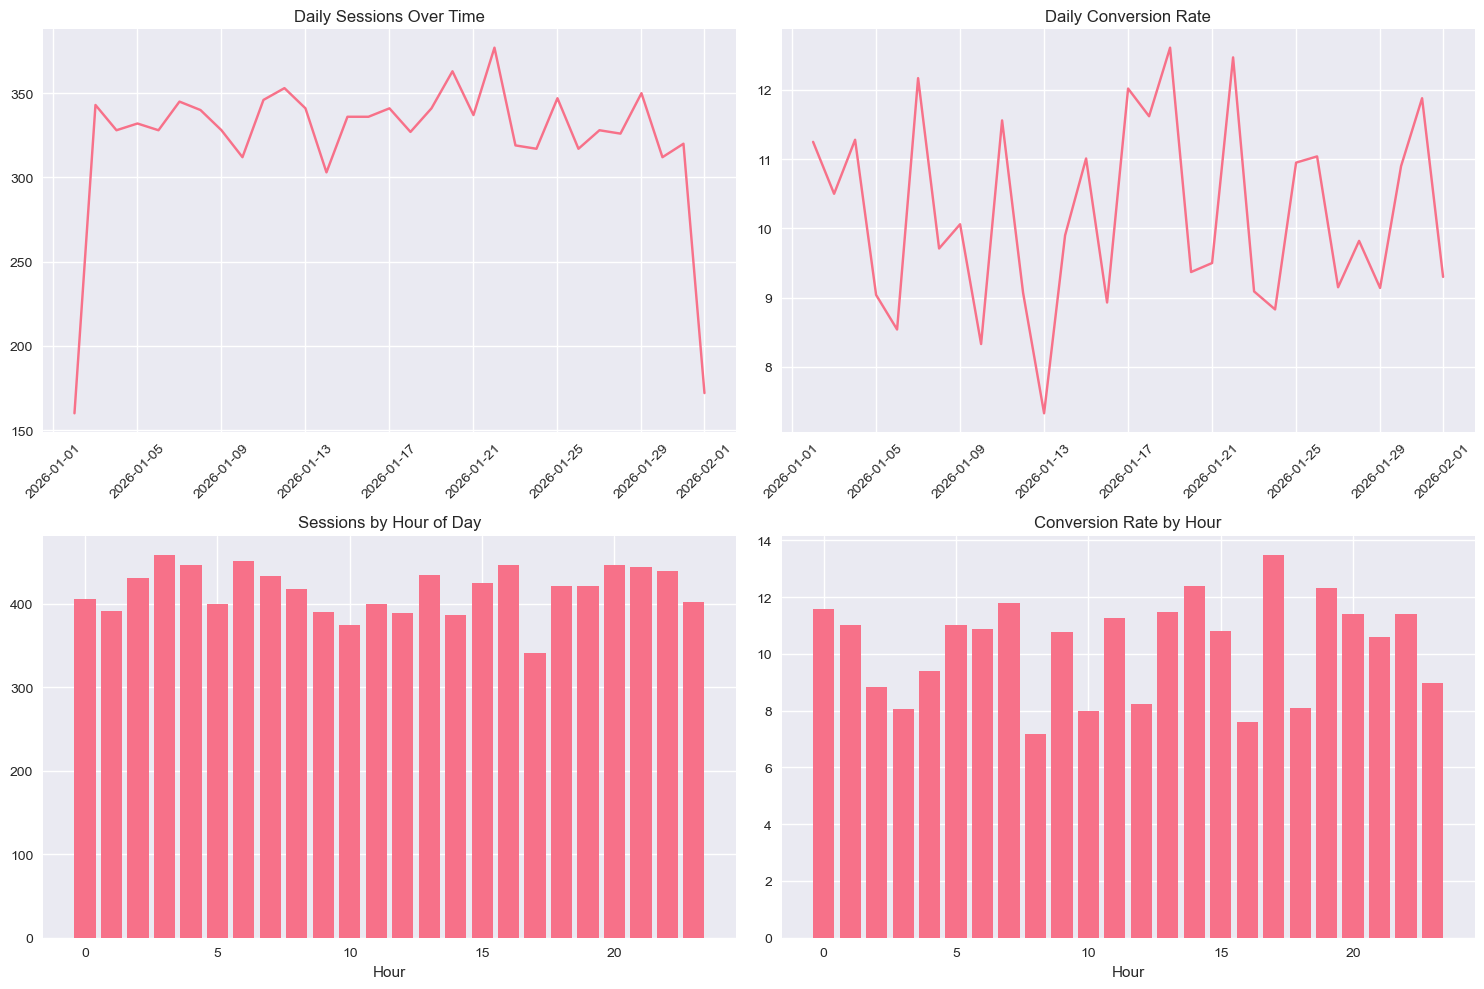

In [53]:
#Ensure datetime
session_summary['Session_Start'] = pd.to_datetime(session_summary['Session_Start'])
df['Date'] = pd.to_datetime(df['Date'])

# ==============================
#  DAILY METRICS
# ==============================

daily_metrics = df.groupby('Date').agg({
    'Session_ID': 'nunique',
    'User_ID': 'nunique',
    'Revenue': 'sum'
}).rename(columns={
    'Session_ID': 'Daily_Sessions',
    'User_ID': 'Daily_Users'
})

# Daily conversions
daily_conversions = session_summary[
    session_summary['Max_Funnel_Stage'] == 'Purchase'
].groupby(session_summary['Session_Start'].dt.date).size()

daily_metrics['Daily_Conversions'] = daily_conversions
daily_metrics['Daily_Conversions'] = daily_metrics['Daily_Conversions'].fillna(0)

daily_metrics['Daily_Conversion_Rate (%)'] = (
    daily_metrics['Daily_Conversions'] / daily_metrics['Daily_Sessions'] * 100
).round(2)

print(" Daily Performance Trends:")
display(daily_metrics.tail(10))


# ==============================
#  HOURLY METRICS
# ==============================

session_summary['Hour'] = session_summary['Session_Start'].dt.hour

hourly_sessions = session_summary.groupby('Hour').agg({
    'Session_ID': 'nunique',
    'Revenue': 'sum'
}).rename(columns={'Session_ID': 'Hourly_Sessions'})

hourly_conversions = session_summary[
    session_summary['Max_Funnel_Stage'] == 'Purchase'
].groupby('Hour').size()

hourly_sessions['Hourly_Conversions'] = hourly_conversions
hourly_sessions['Hourly_Conversions'] = hourly_sessions['Hourly_Conversions'].fillna(0)

hourly_sessions['Hourly_Conversion_Rate (%)'] = (
    hourly_sessions['Hourly_Conversions'] / hourly_sessions['Hourly_Sessions'] * 100
).round(2)


# ==============================
#  VISUALIZATION
# ==============================

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Daily sessions
ax1.plot(daily_metrics.index, daily_metrics['Daily_Sessions'])
ax1.set_title('Daily Sessions Over Time')
ax1.tick_params(axis='x', rotation=45)

# Daily conversion rate
ax2.plot(daily_metrics.index, daily_metrics['Daily_Conversion_Rate (%)'])
ax2.set_title('Daily Conversion Rate')
ax2.tick_params(axis='x', rotation=45)

# Hourly sessions
ax3.bar(hourly_sessions.index, hourly_sessions['Hourly_Sessions'])
ax3.set_title('Sessions by Hour of Day')
ax3.set_xlabel('Hour')

# Hourly conversion rate
ax4.bar(hourly_sessions.index, hourly_sessions['Hourly_Conversion_Rate (%)'])
ax4.set_title('Conversion Rate by Hour')
ax4.set_xlabel('Hour')

plt.tight_layout()
plt.show()


# Advance funnel Metrics and KPI

In [54]:
print("📌 KEY PERFORMANCE INDICATORS (KPIs)")
print("=" * 50)

# ==============================
# 🔹 OVERALL KPIs
# ==============================

total_sessions = len(session_summary)
total_revenue = session_summary['Revenue'].sum()
total_orders = len(session_summary[session_summary['Max_Funnel_Stage'] == 'Purchase'])
overall_conversion_rate = (total_orders / total_sessions) * 100
aov = total_revenue / total_orders if total_orders > 0 else 0

print(f"📈 Overall Conversion Rate: {overall_conversion_rate:.2f}%")
print(f"💰 Total Revenue: ${total_revenue:,.2f}")
print(f"🛒 Average Order Value: ${aov:.2f}")
print(f"👥 Total Sessions: {total_sessions:,}")
print(f"📦 Total Orders: {total_orders:,}")

# ==============================
# 🔹 FUNNEL EFFICIENCY METRICS
# ==============================

stage_sessions = dict(zip(funnel_df['Stage'], funnel_df['Sessions']))

browse = stage_sessions.get('Browse', 0)
cart = stage_sessions.get('Add to Cart', 0)
checkout = stage_sessions.get('Checkout', 0)
purchase = stage_sessions.get('Purchase', 0)

browse_to_cart = (cart / browse * 100) if browse else 0
cart_to_checkout = (checkout / cart * 100) if cart else 0
checkout_to_purchase = (purchase / checkout * 100) if checkout else 0

print("\n🔄 Stage-to-Stage Conversion Rates:")
print(f"Browse → Add to Cart: {browse_to_cart:.2f}%")
print(f"Add to Cart → Checkout: {cart_to_checkout:.2f}%")
print(f"Checkout → Purchase: {checkout_to_purchase:.2f}%")

# ==============================
# 🔹 REVENUE PER SESSION BY STAGE
# ==============================

revenue_per_browse = total_revenue / browse if browse else 0
revenue_per_cart = total_revenue / cart if cart else 0
revenue_per_checkout = total_revenue / checkout if checkout else 0

print("\n💵 Revenue per Session by Stage:")
print(f"Per Browse Session: ${revenue_per_browse:.2f}")
print(f"Per Cart Session: ${revenue_per_cart:.2f}")
print(f"Per Checkout Session: ${revenue_per_checkout:.2f}")

# ==============================
# 🔹 BOUNCE RATE
# ==============================

bounce_sessions = session_summary[session_summary['Bounce_Flag'] == 'Yes']
bounce_rate = (len(bounce_sessions) / total_sessions) * 100

print(f"\n🚪 Bounce Rate: {bounce_rate:.2f}%")

# ==============================
# 🔹 SESSION DURATION
# ==============================

avg_session_duration = session_summary['Session_Duration_Min'].mean()
print(f"⏱ Average Session Duration: {avg_session_duration:.2f} minutes")


📌 KEY PERFORMANCE INDICATORS (KPIs)
📈 Overall Conversion Rate: 10.24%
💰 Total Revenue: $1,167,480.91
🛒 Average Order Value: $1140.12
👥 Total Sessions: 10,000
📦 Total Orders: 1,024

🔄 Stage-to-Stage Conversion Rates:
Browse → Add to Cart: 69.34%
Add to Cart → Checkout: 50.52%
Checkout → Purchase: 29.23%

💵 Revenue per Session by Stage:
Per Browse Session: $116.75
Per Cart Session: $168.37
Per Checkout Session: $333.28

🚪 Bounce Rate: 89.76%
⏱ Average Session Duration: 4.02 minutes


# STRATEGIC RECOMMENDATIONS

In [55]:
print("📌 STRATEGIC RECOMMENDATIONS")
print("=" * 50)

# ==============================
# 🔻 Biggest funnel drop-off
# ==============================
max_dropoff_stage = funnel_df.loc[funnel_df['Drop_Off_Rate (%)'].idxmax()]
print(f"📉 BIGGEST DROP-OFF: {max_dropoff_stage['Stage']} stage "
      f"with {max_dropoff_stage['Drop_Off_Rate (%)']:.2f}% drop-off")


# ==============================
# 🏆 Best performing channel
# ==============================
best_channel = channel_df.loc[channel_df['Conversion_Rate (%)'].idxmax()]
print(f"🚀 BEST CHANNEL: {best_channel['Channel']} "
      f"with {best_channel['Conversion_Rate (%)']:.2f}% conversion")


# ==============================
# 🌍 Best performing region
# ==============================
best_region = regional_analysis.loc[regional_analysis['Conversion_Rate (%)'].idxmax()]
print(f"🌍 BEST REGION: {best_region.name} "
      f"with {best_region['Conversion_Rate (%)']:.2f}% conversion")


# ==============================
# 🛍 Best product category
# ==============================
best_category = product_analysis.loc[product_analysis['Conversion_Rate (%)'].idxmax()]
print(f"🛍 BEST CATEGORY: {best_category.name} "
      f"with {best_category['Conversion_Rate (%)']:.2f}% conversion")


# ==============================
# 💡 RECOMMENDED ACTIONS
# ==============================
print("\n💡 RECOMMENDED ACTIONS:")
print(f"1️⃣ Improve UX at {max_dropoff_stage['Stage']} stage to reduce drop-offs")
print(f"2️⃣ Increase marketing budget on {best_channel['Channel']} channel")
print(f"3️⃣ Replicate {best_region.name} strategies in weaker regions")
print(f"4️⃣ Promote {best_category.name} category to boost conversions")

# ==============================
# 💰 Cart Abandonment Opportunity
# ==============================
cart_sessions = stage_sessions.get('Add to Cart', 0)
checkout_sessions = stage_sessions.get('Checkout', 0)
abandoned_carts = cart_sessions - checkout_sessions

potential_revenue = abandoned_carts * aov
print(f"\n💰 Cart Abandonment Revenue Opportunity: ${potential_revenue:,.2f}")


📌 STRATEGIC RECOMMENDATIONS
📉 BIGGEST DROP-OFF: Purchase stage with 70.77% drop-off
🚀 BEST CHANNEL: Paid Ads with 11.06% conversion
🌍 BEST REGION: UK with 10.70% conversion
🛍 BEST CATEGORY: Clothing with 10.62% conversion

💡 RECOMMENDED ACTIONS:
1️⃣ Improve UX at Purchase stage to reduce drop-offs
2️⃣ Increase marketing budget on Paid Ads channel
3️⃣ Replicate UK strategies in weaker regions
4️⃣ Promote Clothing category to boost conversions

💰 Cart Abandonment Revenue Opportunity: $3,911,745.12


# Export result

In [59]:
pip install xlsxwriter

Note: you may need to restart the kernel to use updated packages.


 Analysis complete! Report saved as 'funnel_analysis_report.xlsx'
 Chart saved as 'funnel_conversion_rates.png'


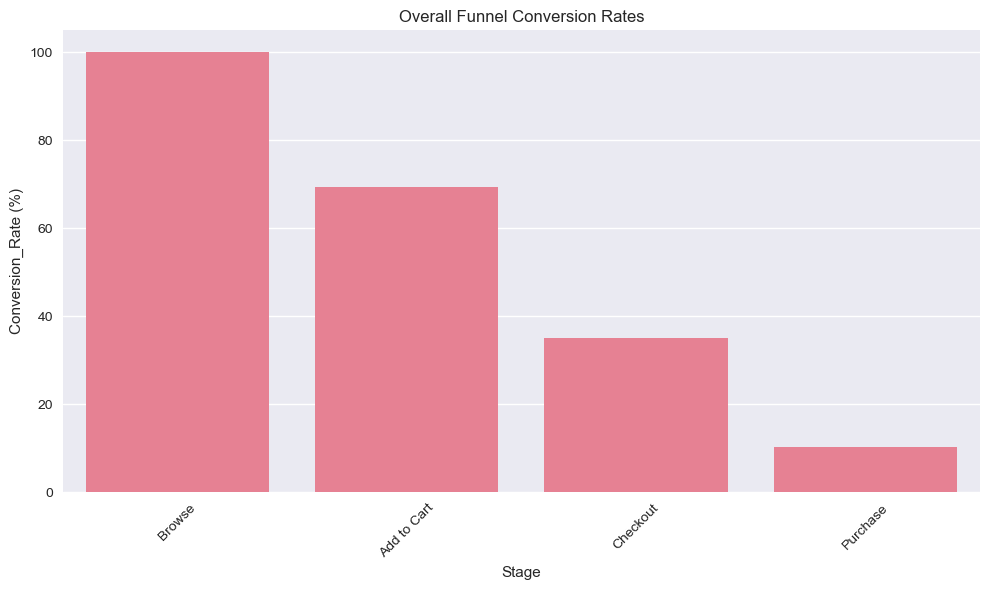

In [58]:
# ==============================
#  COMPREHENSIVE REPORT DATA
# ==============================

report_data = {
    'Overall_Funnel': funnel_df,
    'Channel_Performance': channel_df,
    'Regional_Analysis': regional_analysis.reset_index(),
    'Device_Performance': device_analysis.reset_index(),
    'Product_Performance': product_analysis.reset_index(),
    'Daily_Trends': daily_metrics.reset_index(),
    'Hourly_Patterns': hourly_sessions.reset_index()
}

# ==============================
#  EXPORT TO EXCEL
# ==============================

file_path = "funnel_analysis_report.xlsx"

with pd.ExcelWriter(file_path, engine='xlsxwriter') as writer:
    for sheet_name, data in report_data.items():
        data.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print(f" Analysis complete! Report saved as '{file_path}'")


# ==============================
#  SAVE KEY VISUALIZATION
# ==============================

plt.figure(figsize=(10, 6))
sns.barplot(data=funnel_df, x='Stage', y='Conversion_Rate (%)')
plt.title('Overall Funnel Conversion Rates')
plt.xticks(rotation=45)
plt.tight_layout()

img_path = "funnel_conversion_rates.png"
plt.savefig(img_path, dpi=300, bbox_inches='tight')

print(f" Chart saved as '{img_path}'")
